In [17]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [25]:
import os, shutil, re, math
from PIL import Image, ImageOps
import pandas as pd
import numpy as np
from datetime import datetime
import cv2
from pathlib import Path
from typing import Tuple, Optional
from collections import Counter
import logging
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
class DataPreprocessor:

    def __init__(self, original_images_folder_path, default_output_images_folder_path):
        self.original_images_folder_path = original_images_folder_path
        self.default_output_images_folder_path = default_output_images_folder_path
        os.makedirs(self.default_output_images_folder_path, exist_ok=True)

    def get_image_paths(self, images_folder_path):
        # return [os.path.join(images_folder_path, filename) for filename in sorted(os.listdir(images_folder_path), key=lambda x: int(re.search(r'\((\d+)\)', x).group(1)))]
        return [os.path.join(images_folder_path, filename) for filename in os.listdir(images_folder_path)]
    
    def init_output_images_folder(self, output_images_folder_path):
        output_images_folder_path = output_images_folder_path or self.default_output_images_folder_path
        if os.path.exists(output_images_folder_path):
            shutil.rmtree(output_images_folder_path)
        os.makedirs(output_images_folder_path, exist_ok=True)
        return output_images_folder_path

    def crop_images_to_square(self, input_images_folder_path=None, output_images_folder_path=None):
        input_images_folder_path = input_images_folder_path or self.original_images_folder_path
        output_images_folder_path = self.init_output_images_folder(output_images_folder_path)

        for image_path in self.get_image_paths(input_images_folder_path):
            with Image.open(image_path) as img:
                width, height = img.size
                min_dim = min(width, height)
                left, top = (width - min_dim) // 2, (height - min_dim) // 2
                right, bottom = left + min_dim, top + min_dim
                cropped_img = img.crop((left, top, right, bottom))
                cropped_img.save(os.path.join(output_images_folder_path, os.path.basename(image_path)))

        print(f"{datetime.now().strftime('%H:%M')} CROPPED: {input_images_folder_path} -> {output_images_folder_path}")

    def pad_images_to_square(self, input_images_folder_path=None, output_images_folder_path=None):
        input_images_folder_path = input_images_folder_path or self.original_images_folder_path
        output_images_folder_path = self.init_output_images_folder(output_images_folder_path)

        for image_path in self.get_image_paths(input_images_folder_path):
            with Image.open(image_path) as img:
                max_dim = max(img.size)
                padded_img = ImageOps.pad(img, (max_dim, max_dim), color=(0), centering=(0.5,0.5))
                padded_img.save(os.path.join(output_images_folder_path, os.path.basename(image_path)))

        print(f"{datetime.now().strftime('%H:%M')} PADDED: {input_images_folder_path} -> {output_images_folder_path}")

    def resize_squared_images_to_square(self, target_width, input_images_folder_path=None, output_images_folder_path=None):
        input_images_folder_path = input_images_folder_path or self.original_images_folder_path
        output_images_folder_path = self.init_output_images_folder(output_images_folder_path)

        for image_path in self.get_image_paths(input_images_folder_path):
            with Image.open(image_path) as img:
                if img.width == img.height:
                    resized_img = img.resize((target_width, target_width))
                    resized_img.save(os.path.join(output_images_folder_path, os.path.basename(image_path)))

        print(f"{datetime.now().strftime('%H:%M')} RESIZED: {input_images_folder_path} -> {output_images_folder_path}")

    def grayscale_images(self, input_images_folder_path=None, output_images_folder_path=None):
        input_images_folder_path = input_images_folder_path or self.original_images_folder_path
        output_images_folder_path = self.init_output_images_folder(output_images_folder_path)

        for image_path in self.get_image_paths(input_images_folder_path):
            with Image.open(image_path) as img:
                grayscaled_img = img.convert("L")
                grayscaled_img.save(os.path.join(output_images_folder_path, os.path.basename(image_path)))

        print(f"{datetime.now().strftime('%H:%M')} GRAYSCALED: {input_images_folder_path} -> {output_images_folder_path}")


original_images_folder_path = "./data/teknofest/images/original"
default_output_images_folder_path = "./data/teknofest/images/processed"
preprocessor = DataPreprocessor(original_images_folder_path, default_output_images_folder_path)

preprocessor.resize_squared_images_to_square(512, "./data/trash/sus/images-padded", "./data/trash/sus/images-padded-512")

15:12 RESIZED: ./data/trash/sus/images-padded -> ./data/trash/sus/images-padded-512


In [25]:
def get_filenames_without_extensions(folder):
    return {os.path.splitext(f)[0] for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))}

def find_unmatched_files(folder1, folder2):
    names1 = get_filenames_without_extensions(folder1)
    names2 = get_filenames_without_extensions(folder2)

    only_in_folder1 = names1 - names2
    only_in_folder2 = names2 - names1

    return only_in_folder1, only_in_folder2

unmatched1, unmatched2 = find_unmatched_files("./data/trash/sus/images-original", "./data/trash/sus/annotations-original")

print("Files only in folder1 (ignoring extensions):", unmatched1)
print("Files only in folder2 (ignoring extensions):", unmatched2)

Files only in folder1 (ignoring extensions): set()
Files only in folder2 (ignoring extensions): set()


In [10]:
def get_unique_colors(image_path):
    img = Image.open(image_path).convert('RGB')
    pixels = img.getdata()
    unique_colors = set(pixels)
    return unique_colors

unique_colors = get_unique_colors("./data/trash/sus/annotations-padded-512/1010.png")

print(f"Found {len(unique_colors)} unique colors:")
for color in sorted(unique_colors):
    print(f'#{color[0]:02X}{color[1]:02X}{color[2]:02X}')

Found 2 unique colors:
#000000
#FFFFFF


In [ ]:
COLOR_TO_LABEL = {
    (0, 0, 0): 0,
    (85, 85, 85): 1,
    (170, 170, 170): 2,
    (255, 255, 255): 3
}

LABEL_TO_COLOR = {
    0: (0, 0, 0),
    1: (85, 85, 85),
    2: (170, 170, 170),
    3: (255, 255, 255)
}

def color_to_label_array(img):
    """Convert RGB image to label map."""
    arr = np.array(img)
    label_arr = np.zeros((arr.shape[0], arr.shape[1]), dtype=np.uint8)

    for color, label in COLOR_TO_LABEL.items():
        mask = np.all(arr == color, axis=-1)
        label_arr[mask] = label
    return label_arr

def label_to_color_image(label_arr):
    """Convert label map to RGB image."""
    rgb = np.zeros((label_arr.shape[0], label_arr.shape[1], 3), dtype=np.uint8)
    for label, color in LABEL_TO_COLOR.items():
        rgb[label_arr == label] = color
    return Image.fromarray(rgb)

def resize_segmentation_masks(input_folder, output_folder, target_size=(512, 512)):
    os.makedirs(output_folder, exist_ok=True)

    for filename in os.listdir(input_folder):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            input_path = os.path.join(input_folder, filename)
            output_path = os.path.join(output_folder, filename)

            with Image.open(input_path) as img:
                img = img.convert('RGB')
                label_arr = color_to_label_array(img)

                label_img = Image.fromarray(label_arr)
                resized_label = label_img.resize(target_size, resample=Image.NEAREST)
                resized_rgb = label_to_color_image(np.array(resized_label))
                resized_rgb.save(output_path)

resize_segmentation_masks("./data/trash/sus/images-padded", "./data/trash/sus/images-padded-512")

In [9]:
def resize_binary_masks(input_folder, output_folder, target_size):
    os.makedirs(output_folder, exist_ok=True)
    
    for filename in os.listdir(input_folder):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            input_path = os.path.join(input_folder, filename)
            output_path = os.path.join(output_folder, filename)

            with Image.open(input_path) as img:
                # Convert to binary mode (1-bit pixels)
                img = img.convert('1')  # Ensures black/white only

                resized_img = img.resize(target_size, resample=Image.NEAREST)
                resized_img.save(output_path)

resize_binary_masks("./data/trash/sus/annotations-padded", "./data/trash/sus/annotations-padded-512", (512, 512))

In [ ]:
# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

def separate_lung_regions(binary_mask: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Separate left and right lung regions from a binary mask.
    
    Args:
        binary_mask: Binary mask where lungs are 255 and background is 0
        
    Returns:
        Tuple of (left_lung_mask, right_lung_mask) as binary arrays
    """
    # Find connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        binary_mask, connectivity=8
    )
    
    # Filter out background (label 0) and small components
    min_area = 1000  # Minimum area for a lung region
    lung_components = []
    
    for i in range(1, num_labels):  # Skip background (label 0)
        area = stats[i, cv2.CC_STAT_AREA]
        if area > min_area:
            lung_components.append({
                'label': i,
                'area': area,
                'centroid': centroids[i]
            })
    
    if len(lung_components) < 2:
        raise ValueError(f"Expected 2 lung regions, found {len(lung_components)}")
    
    # Sort by area (largest first) to handle cases with small artifacts
    lung_components.sort(key=lambda x: x['area'], reverse=True)
    
    # Take the two largest components as the lungs
    lung1, lung2 = lung_components[0], lung_components[1]
    
    # Determine left and right based on x-coordinate of centroids
    # In medical imaging, patient's left lung appears on the right side of the image
    if lung1['centroid'][0] < lung2['centroid'][0]:
        # lung1 is on the left side of image (patient's right lung)
        right_lung_label = lung1['label']
        left_lung_label = lung2['label']
    else:
        # lung1 is on the right side of image (patient's left lung)
        left_lung_label = lung1['label']
        right_lung_label = lung2['label']
    
    # Create separate masks
    left_lung_mask = (labels == left_lung_label).astype(np.uint8) * 255
    right_lung_mask = (labels == right_lung_label).astype(np.uint8) * 255
    
    return left_lung_mask, right_lung_mask

def process_single_mask(input_path: str, output_path: str, 
                       left_color: Tuple[int, int, int] = (85, 85, 85),
                       right_color: Tuple[int, int, int] = (170, 170, 170)) -> bool:
    """
    Process a single binary lung mask and save the colored version.
    
    Args:
        input_path: Path to input binary mask
        output_path: Path to save the colored mask
        left_color: RGB color for left lung (default: (85, 85, 85))
        right_color: RGB color for right lung (default: (170, 170, 170))
        
    Returns:
        True if successful, False otherwise
    """
    try:
        # Read the binary mask
        binary_mask = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
        if binary_mask is None:
            logger.error(f"Could not read image: {input_path}")
            return False
        
        # Separate lung regions
        left_lung_mask, right_lung_mask = separate_lung_regions(binary_mask)
        
        # Create colored output image
        height, width = binary_mask.shape
        colored_mask = np.zeros((height, width, 3), dtype=np.uint8)
        
        # Fill left lung with specified color
        colored_mask[left_lung_mask == 255] = left_color
        
        # Fill right lung with specified color
        colored_mask[right_lung_mask == 255] = right_color
        
        # Convert from RGB to BGR for OpenCV
        colored_mask_bgr = cv2.cvtColor(colored_mask, cv2.COLOR_RGB2BGR)
        
        # Save the result
        success = cv2.imwrite(output_path, colored_mask_bgr)
        if not success:
            logger.error(f"Could not save image: {output_path}")
            return False
            
        return True
        
    except Exception as e:
        logger.error(f"Error processing {input_path}: {str(e)}")
        return False

def process_lung_masks_folder(input_folder: str, output_folder: str,
                             left_color: Tuple[int, int, int] = (85, 85, 85),
                             right_color: Tuple[int, int, int] = (170, 170, 170),
                             file_extensions: Tuple[str, ...] = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')) -> None:
    """
    Process all lung masks in a folder and save colored versions.
    
    Args:
        input_folder: Path to folder containing binary lung masks
        output_folder: Path to folder where colored masks will be saved
        left_color: RGB color for left lung (default: (85, 85, 85))
        right_color: RGB color for right lung (default: (170, 170, 170))
        file_extensions: Tuple of valid file extensions to process
    """
    input_path = Path(input_folder)
    output_path = Path(output_folder)
    
    # Create output directory if it doesn't exist
    output_path.mkdir(parents=True, exist_ok=True)
    
    # Find all image files
    image_files = []
    for ext in file_extensions:
        image_files.extend(input_path.glob(f'*{ext}'))
        image_files.extend(input_path.glob(f'*{ext.upper()}'))
    
    if not image_files:
        logger.warning(f"No image files found in {input_folder}")
        return
    
    logger.info(f"Found {len(image_files)} images to process")
    
    # Process each image
    successful = 0
    failed = 0
    
    for img_file in image_files:
        output_file = output_path / img_file.name
        
        if process_single_mask(str(img_file), str(output_file), right_color, left_color):
            successful += 1
            if successful % 50 == 0:  # Progress update every 50 images
                logger.info(f"Processed {successful}/{len(image_files)} images")
        else:
            failed += 1
    
    logger.info(f"Processing complete: {successful} successful, {failed} failed")


# Process all masks in the folder
process_lung_masks_folder(
    input_folder="./data/trash/sus/annotations-padded-512",
    output_folder="./data/trash/sus/annotations-padded-512-recolored",
    left_color=(85, 85, 85),      # Left lung color
    right_color=(170, 170, 170)   # Right lung color
)

INFO:__main__:Found 704 images to process


INFO:__main__:Processed 50/704 images
INFO:__main__:Processed 100/704 images
INFO:__main__:Processed 150/704 images
INFO:__main__:Processed 200/704 images
INFO:__main__:Processed 250/704 images
INFO:__main__:Processed 300/704 images
INFO:__main__:Processed 350/704 images
INFO:__main__:Processed 400/704 images
INFO:__main__:Processed 450/704 images
INFO:__main__:Processed 500/704 images
INFO:__main__:Processed 550/704 images
INFO:__main__:Processed 600/704 images
INFO:__main__:Processed 650/704 images
INFO:__main__:Processed 700/704 images
INFO:__main__:Processing complete: 704 successful, 0 failed


In [50]:
def add_prefix_to_files(folder_path, prefix):
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)

        # Skip if it's not a file
        if not os.path.isfile(file_path):
            continue

        new_filename = prefix + filename
        new_file_path = os.path.join(folder_path, new_filename)

        os.rename(file_path, new_file_path)

add_prefix_to_files("./data/trash/shenzhen-montgomery/images-split-gender/shenzhen", "shenzhen-")
add_prefix_to_files("./data/trash/shenzhen-montgomery/images-split-gender/montgomery", "montgomery-")

In [45]:
def clean_gender_column(csv_path: str, output_path: str = None):

    df = pd.read_csv(csv_path)

    def normalize_gender(value):
        value = str(value).strip().lower()
        if value == "f":
            return "F"
        elif 'fem' in value:
            return 'F'
        else:
            return 'M'

    df['gender'] = df['gender'].apply(normalize_gender)

    # Count and print number of 'F' and 'M'
    count_f = (df['gender'] == 'F').sum()
    count_m = (df['gender'] == 'M').sum()
    print(f"Count of F: {count_f}")
    print(f"Count of M: {count_m}")

    if output_path is None:
        output_path = csv_path

    df.to_csv(output_path, index=False)

clean_gender_column("./data/trash/shenzhen-montgomery/MetaData.csv", "./data/trash/shenzhen-montgomery/MetaData-cleaned.csv")

Count of F: 262
Count of M: 442


In [47]:
def rename_files_with_gender_prefix(csv_path: str, folder_path: str):
    """
    Rename files in a folder by adding a gender prefix ("M-" or "F-")
    based on a CSV file containing 'id' (filename without extension) and 'gender'.
    """

    # Load and clean the CSV data
    df = pd.read_csv(csv_path)
    df['id'] = df['id'].astype(str).str.strip()               # Ensure 'id' is str and clean
    df['gender'] = df['gender'].astype(str).str.strip().str.lower()
    id_to_gender = dict(zip(df['id'], df['gender']))

    # Rename files in the folder
    for filename in os.listdir(folder_path):
        name, ext = os.path.splitext(filename)
        name = name.strip()  # strip filename before lookup
        if name in id_to_gender:
            gender = id_to_gender[name]
            new_name = f"{gender.upper()}-{filename}"
            old_path = os.path.join(folder_path, filename)
            new_path = os.path.join(folder_path, new_name)
            os.rename(old_path, new_path)

rename_files_with_gender_prefix("./data/trash/shenzhen-montgomery/MetaData-cleaned.csv", "./data/trash/shenzhen-montgomery/images-split/shenzhen")
rename_files_with_gender_prefix("./data/trash/shenzhen-montgomery/MetaData-cleaned.csv", "./data/trash/shenzhen-montgomery/images-split/montgomery")
rename_files_with_gender_prefix("./data/trash/shenzhen-montgomery/MetaData-cleaned.csv", "./data/trash/shenzhen-montgomery/annotations-split/shenzhen")
rename_files_with_gender_prefix("./data/trash/shenzhen-montgomery/MetaData-cleaned.csv", "./data/trash/shenzhen-montgomery/annotations-split/montgomery")

In [51]:
def add_prefix_to_column(csv_input_path: str, csv_output_path: str, column_name: str, prefix: str):
    """
    Adds a prefix at the start of all values in the specified column of a CSV file
    and saves the result as a new CSV file.

    Parameters:
    - csv_input_path: path to the input CSV file
    - csv_output_path: path to save the updated CSV file
    - column_name: name of the column to update
    - prefix: string prefix to add at the start of each value in the column
    """

    df = pd.read_csv(csv_input_path)
    # Convert values to string and add prefix at the start
    df[column_name] = prefix + df[column_name].astype(str)
    df.to_csv(csv_output_path, index=False)

add_prefix_to_column("./data/teknofest/data.csv", "./data/teknofest/data-cleaned.csv", "filename", "teknofest-")

In [2]:
folder_path = "./data/all/masks"  # change this

# File extensions to consider
valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.gif')

# Dictionary to store {filename: unique_color_count}
image_color_counts = {}

for filename in os.listdir(folder_path):
    if filename.lower().endswith(valid_extensions):
        image_path = os.path.join(folder_path, filename)
        with Image.open(image_path) as img:
            img = img.convert("RGB")  # ensure RGB format
            pixels = list(img.getdata())
            unique_colors = set(pixels)
            image_color_counts[filename] = len(unique_colors)

# Count how many images have X unique colors
summary_counts = Counter(image_color_counts.values())

# Print per image
print("Unique color count per image:")
for name, count in image_color_counts.items():
    print(f"{name}: {count} unique colors")

# Print summary
print("\nSummary of unique color counts:")
for color_count, num_images in summary_counts.items():
    print(f"{color_count} unique colors: {num_images} image(s)")

Unique color count per image:
shenzhen-M-1408.png: 3 unique colors
shenzhen-F-1183.png: 3 unique colors
padchest-17871983995291973291210205507121602296_hd8ger.png: 4 unique colors
shenzhen-F-1542.png: 3 unique colors
shenzhen-F-1272.png: 3 unique colors
shenzhen-M-1202.png: 3 unique colors
shenzhen-M-1101.png: 3 unique colors
shenzhen-F-1042.png: 3 unique colors
montgomery-F-1688.png: 3 unique colors
shenzhen-M-1055.png: 3 unique colors
shenzhen-F-1501.png: 3 unique colors
jsrt-JPCLN106.png: 4 unique colors
montgomery-M-1698.png: 3 unique colors
jsrt-JPCNN054.png: 4 unique colors
shenzhen-F-1108.png: 3 unique colors
shenzhen-M-1181.png: 3 unique colors
jsrt-JPCLN050.png: 4 unique colors
jsrt-JPCNN083.png: 4 unique colors
jsrt-JPCNN043.png: 4 unique colors
montgomery-M-1615.png: 3 unique colors
shenzhen-M-1195.png: 3 unique colors
shenzhen-M-1491.png: 3 unique colors
montgomery-F-1581.png: 3 unique colors
montgomery-F-1686.png: 3 unique colors
padchest-2695775030522820800202450064560748

In [2]:
def get_leftmost_white_x(image_path):
    img = Image.open(image_path).convert('RGB')  # ensure RGB
    width, height = img.size

    for x in range(width):
        for y in range(height):
            r, g, b = img.getpixel((x, y))
            if (r, g, b) == (255, 255, 255):
                return x
    return None  # No white pixel found

In [5]:
get_leftmost_white_x("./data/all/masks/jsrt-JPCLN002.png")

180

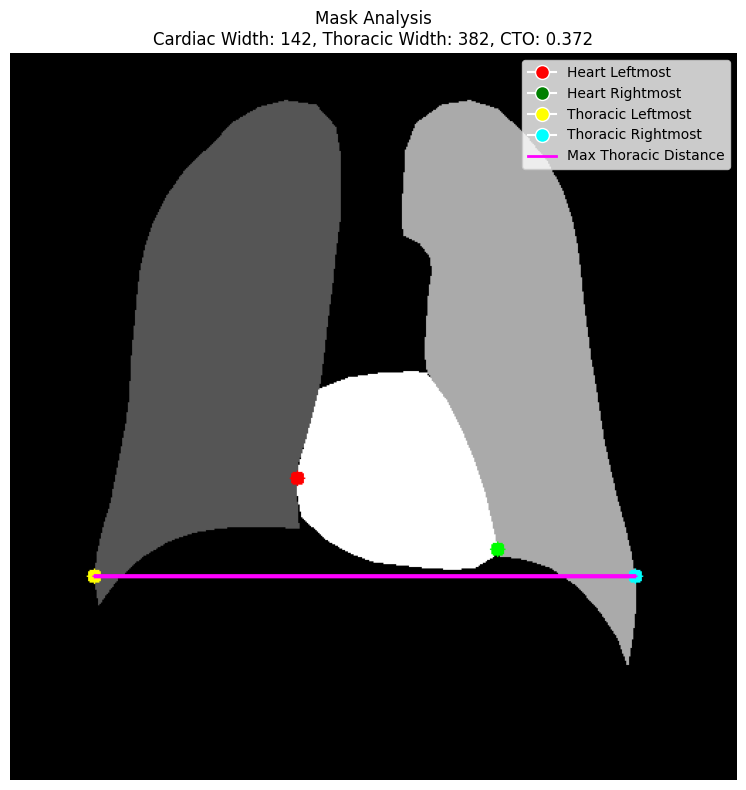

Cardiac Width: 142
Thoracic Width: 382
CTO: 0.372


In [10]:
def analyze_mask_with_visualization(mask_path, color_left_lung=(85,85,85), color_right_lung=(170,170,170), color_heart=(255,255,255)):
    """
    Analyze a mask image to calculate cardiac width, thoracic width, and CTO ratio,
    with visualization of key measurement points.
    
    Args:
        mask_path (str): Path to the mask image
        color_left_lung (tuple): RGB color for left lung pixels
        color_right_lung (tuple): RGB color for right lung pixels  
        color_heart (tuple): RGB color for heart pixels
        
    Returns:
        dict: Dictionary containing cardiac_width, thoracic_width, cto, and the visualization image
    """
    
    # Load the mask image
    img = cv2.imread(mask_path)
    if img is None:
        raise ValueError(f"Could not load image from {mask_path}")
    
    # Convert BGR to RGB for consistency
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Create a copy for visualization
    vis_img = img.copy()
    
    # Calculate cardiac width
    cardiac_width = None
    heart_leftmost = None
    heart_rightmost = None
    
    heart_mask = np.all(img == color_heart, axis=2)
    if np.any(heart_mask):
        heart_coords = np.where(heart_mask)
        heart_x_coords = heart_coords[1]  # x-coordinates
        heart_y_coords = heart_coords[0]  # y-coordinates
        
        # Find leftmost and rightmost points
        min_x_idx = np.argmin(heart_x_coords)
        max_x_idx = np.argmax(heart_x_coords)
        
        heart_leftmost = (heart_x_coords[min_x_idx], heart_y_coords[min_x_idx])
        heart_rightmost = (heart_x_coords[max_x_idx], heart_y_coords[max_x_idx])
        
        cardiac_width = heart_rightmost[0] - heart_leftmost[0] + 1
        
        # Mark leftmost and rightmost heart points on visualization
        cv2.circle(vis_img, heart_leftmost, 5, (255, 0, 0), -1)  # Red circle for leftmost
        cv2.circle(vis_img, heart_rightmost, 5, (0, 255, 0), -1)  # Green circle for rightmost
    
    # Calculate thoracic width
    thoracic_width = 0
    max_distance_y = None
    thoracic_leftmost = None
    thoracic_rightmost = None
    
    left_lung_mask = np.all(img == color_left_lung, axis=2)
    right_lung_mask = np.all(img == color_right_lung, axis=2)
    
    # Get unique y-coordinates where either lung is present
    left_lung_coords = np.where(left_lung_mask)
    right_lung_coords = np.where(right_lung_mask)
    
    if len(left_lung_coords[0]) > 0 and len(right_lung_coords[0]) > 0:
        # Get all y-coordinates where lungs are present
        all_y_coords = np.unique(np.concatenate([left_lung_coords[0], right_lung_coords[0]]))
        
        max_distance = 0
        for y in all_y_coords:
            # Find x-coordinates of left lung at this y-level
            left_lung_x_at_y = left_lung_coords[1][left_lung_coords[0] == y]
            # Find x-coordinates of right lung at this y-level
            right_lung_x_at_y = right_lung_coords[1][right_lung_coords[0] == y]
            
            if len(left_lung_x_at_y) > 0 and len(right_lung_x_at_y) > 0:
                # Distance between leftmost point of left lung and rightmost point of right lung
                leftmost_left = np.min(left_lung_x_at_y)
                rightmost_right = np.max(right_lung_x_at_y)
                distance = rightmost_right - leftmost_left + 1
                
                if distance > max_distance:
                    max_distance = distance
                    max_distance_y = y
                    thoracic_leftmost = (leftmost_left, y)
                    thoracic_rightmost = (rightmost_right, y)
        
        thoracic_width = max_distance
        
        # Mark thoracic measurement points on visualization
        if thoracic_leftmost and thoracic_rightmost:
            cv2.circle(vis_img, thoracic_leftmost, 5, (255, 255, 0), -1)  # Yellow circle for leftmost lung point
            cv2.circle(vis_img, thoracic_rightmost, 5, (0, 255, 255), -1)  # Cyan circle for rightmost lung point
            # Draw line between thoracic measurement points
            cv2.line(vis_img, thoracic_leftmost, thoracic_rightmost, (255, 0, 255), 2)  # Magenta line
    
    # Calculate CTO
    cto = None
    if cardiac_width is not None and thoracic_width is not None and thoracic_width > 0:
        cto = round(cardiac_width / thoracic_width, 3)
    
    # Create visualization
    plt.figure(figsize=(12, 8))
    plt.imshow(vis_img)
    plt.title(f'Mask Analysis\nCardiac Width: {cardiac_width}, Thoracic Width: {thoracic_width}, CTO: {cto}')
    
    # Add legend
    legend_elements = []
    if heart_leftmost and heart_rightmost:
        legend_elements.extend([
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Heart Leftmost'),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Heart Rightmost')
        ])
    if thoracic_leftmost and thoracic_rightmost:
        legend_elements.extend([
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='yellow', markersize=10, label='Thoracic Leftmost'),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='cyan', markersize=10, label='Thoracic Rightmost'),
            plt.Line2D([0], [0], color='magenta', linewidth=2, label='Max Thoracic Distance')
        ])
    
    if legend_elements:
        plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1, 1))
    
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Return results
    results = {
        'cardiac_width': cardiac_width,
        'thoracic_width': thoracic_width if thoracic_width > 0 else None,
        'cto': cto,
        'visualization': vis_img,
        'heart_leftmost': heart_leftmost,
        'heart_rightmost': heart_rightmost,
        'thoracic_leftmost': thoracic_leftmost,
        'thoracic_rightmost': thoracic_rightmost
    }
    
    return results

results = analyze_mask_with_visualization("./data/all/masks/jsrt-JPCLN006.png")
print(f"Cardiac Width: {results['cardiac_width']}")
print(f"Thoracic Width: {results['thoracic_width']}")
print(f"CTO: {results['cto']}")

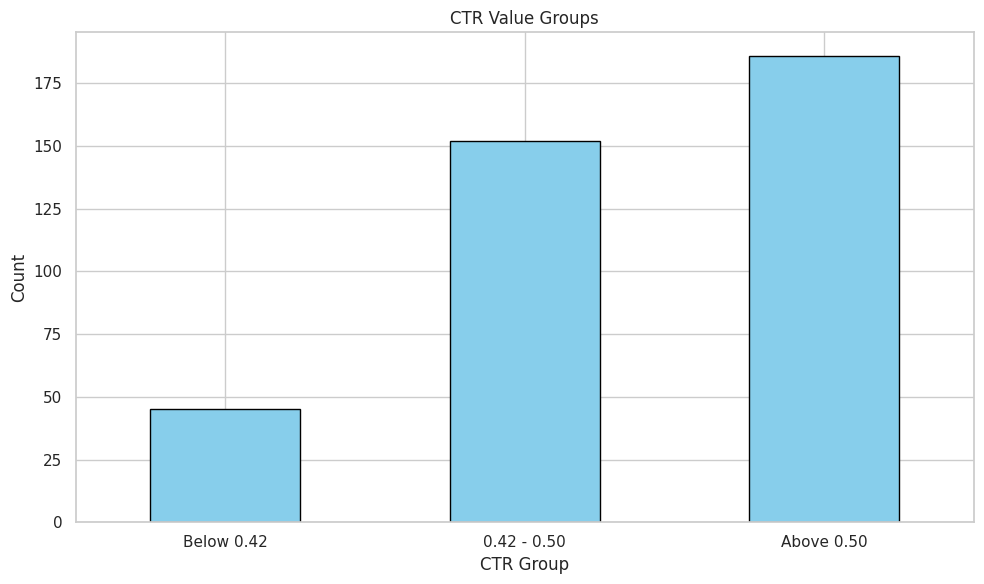

In [41]:
df = pd.read_csv("./data/all/extracted_data.csv")

# Drop missing ctr values
df = df.dropna(subset=['ctr'])

# Define CTR groups
def group_cto(value):
    if value < 0.42:
        return 'Below 0.42'
    elif value <= 0.50:
        return '0.42 - 0.50'
    else:
        return 'Above 0.50'

df['ctr_group'] = df['ctr'].apply(group_cto)

# Count each group
group_counts = df['ctr_group'].value_counts().reindex(['Below 0.42', '0.42 - 0.50', 'Above 0.50'])

# Plot
group_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('CTR Group')
plt.ylabel('Count')
plt.title('CTR Value Groups')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

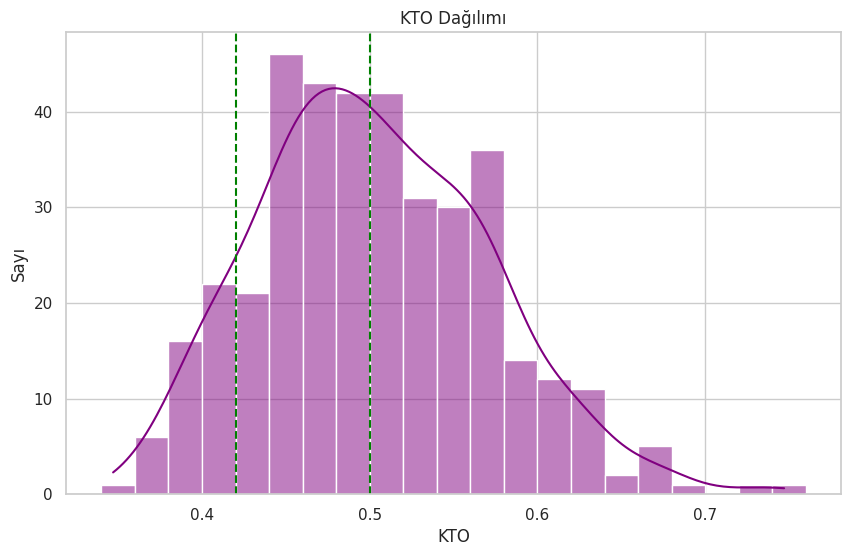

In [51]:
df = pd.read_csv("./data/all/extracted_data.csv")
healthy_min, healthy_max = 0.42, 0.50

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
bin_edges = np.arange(df['ctr'].min()//0.02*0.02, df['ctr'].max()//0.02*0.02+0.04, 0.02)
sns.histplot(df['ctr'].dropna(), bins=bin_edges, kde=True, color='purple')
[plt.axvline(x=i, color='green', linestyle='--', label=f'Healthy {"Min" if i==healthy_min else "Max"}') for i in (healthy_min, healthy_max)]
plt.title('KTO Dağılımı')
plt.xlabel('KTO')
plt.ylabel('Sayı')
plt.show()